# Part 2

In [166]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import spaghetti
import esda
import matplotlib.pyplot as plt
import random

from shapely.geometry import Point, LineString

## Task A (spatial networks and planarity)

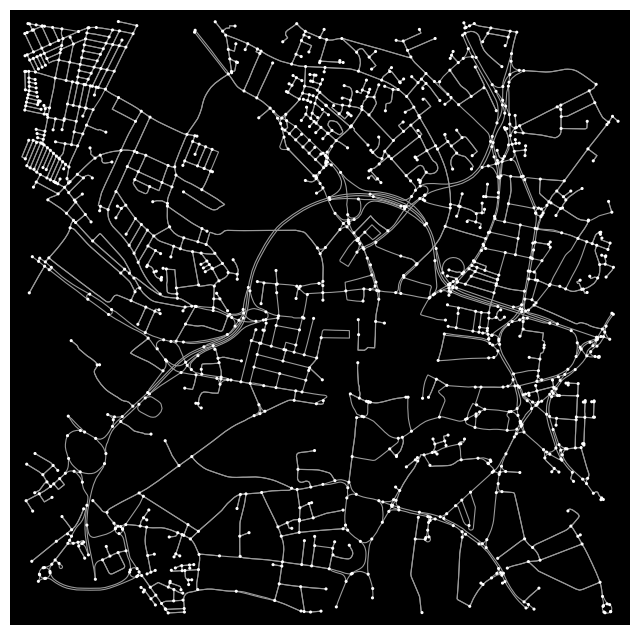

In [169]:
center_point = (53.7997, -1.5492)

G = ox.graph_from_point(
    center_point,
    dist=1500,
    network_type="drive",
    simplify=True
)
fig, ax = ox.plot_graph(
    G,
    node_size=5,
    edge_linewidth=0.8,
    bgcolor="black"
)

In [170]:
data_folder = "/Users/dhy/Desktop/KCL-Data Science/Network Data Analysis/coursework/Part 2 Data"
files = glob.glob(os.path.join(data_folder, "*.csv"))

files

['/Users/dhy/Desktop/KCL-Data Science/Network Data Analysis/coursework/Part 2 Data/2015.csv',
 '/Users/dhy/Desktop/KCL-Data Science/Network Data Analysis/coursework/Part 2 Data/2014.csv',
 '/Users/dhy/Desktop/KCL-Data Science/Network Data Analysis/coursework/Part 2 Data/2013.csv',
 '/Users/dhy/Desktop/KCL-Data Science/Network Data Analysis/coursework/Part 2 Data/Copy of Leeds_RTC_2016.csv',
 '/Users/dhy/Desktop/KCL-Data Science/Network Data Analysis/coursework/Part 2 Data/2012.csv',
 '/Users/dhy/Desktop/KCL-Data Science/Network Data Analysis/coursework/Part 2 Data/2011.csv']

In [173]:
dfs = []
for f in files:
    try:
        df = pd.read_csv(f, low_memory=False, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(f, low_memory=False, encoding="latin1")
        
    df["source_file"] = os.path.basename(f)
    dfs.append(df)

acc = pd.concat(dfs, ignore_index=True)

print("=== Raw merged data===")
print("number of files:", len(files))
print("total rows:", len(acc))
print("unique reference numbers in raw data:", acc["Reference Number"].nunique())
print()

# Remove duplicate accidents and missing accident ID

acc_unique = (
    acc
    .drop_duplicates(subset="Reference Number")
    .dropna(subset=["Reference Number"])
    .copy()
)

print("=== After accident-level cleaning ===")
print("rows in acc_unique:", len(acc_unique))
print("unique reference numbers:", acc_unique["Reference Number"].nunique())
print("missing Reference Number:", acc_unique["Reference Number"].isna().sum())
print()

=== Raw merged data===
number of files: 6
total rows: 15613
unique reference numbers in raw data: 11496

=== After accident-level cleaning ===
rows in acc_unique: 11496
unique reference numbers: 11496
missing Reference Number: 0



In [175]:
# Check and clean coordinate columns

coord_cols = ["Grid Ref: Easting", "Grid Ref: Northing"]

acc_unique["Grid Ref: Easting"] = pd.to_numeric(
    acc_unique["Grid Ref: Easting"], errors="coerce"
)
acc_unique["Grid Ref: Northing"] = pd.to_numeric(
    acc_unique["Grid Ref: Northing"], errors="coerce"
)

print("=== Coordinate check ===")
print(acc_unique[coord_cols].isna().sum())
print()

acc_clean = acc_unique.dropna(subset=coord_cols).copy()

print("unique accidents:", len(acc_unique))
print("with coordinates:", len(acc_clean))
print()

=== Coordinate check ===
Grid Ref: Easting     3866
Grid Ref: Northing    3866
dtype: int64

unique accidents: 11496
with coordinates: 7630



In [177]:
gdf_acc = gpd.GeoDataFrame(
    acc_clean,
    geometry=gpd.points_from_xy(
        acc_clean["Grid Ref: Easting"],
        acc_clean["Grid Ref: Northing"]
    ),
    crs="EPSG:27700"
)

gdf_acc_wgs = gdf_acc.to_crs(epsg=4326)

print("=== GeoDataFrame check ===")
print("CRS:", gdf_acc.crs)
print("WGS84 CRS:", gdf_acc_wgs.crs)
print()

=== GeoDataFrame check ===
CRS: EPSG:27700
WGS84 CRS: EPSG:4326



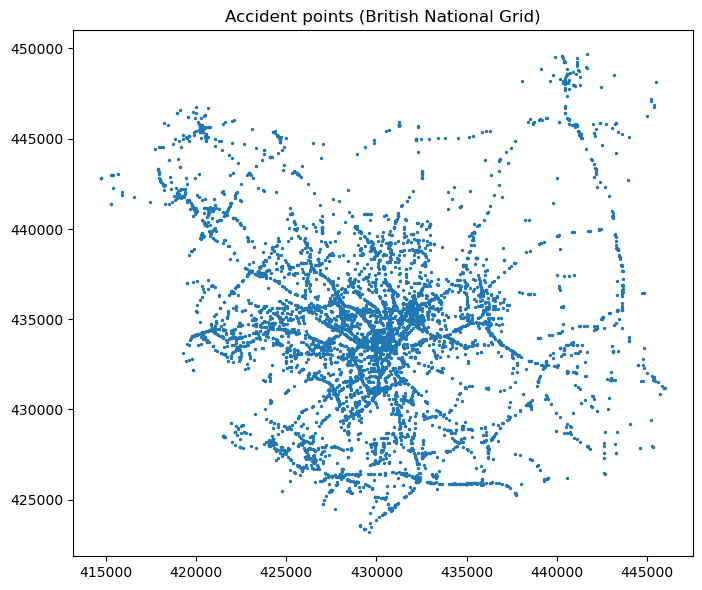

In [179]:
gdf_acc.plot(figsize=(8, 8), markersize=2)
plt.title("Accident points (British National Grid)")
plt.show()

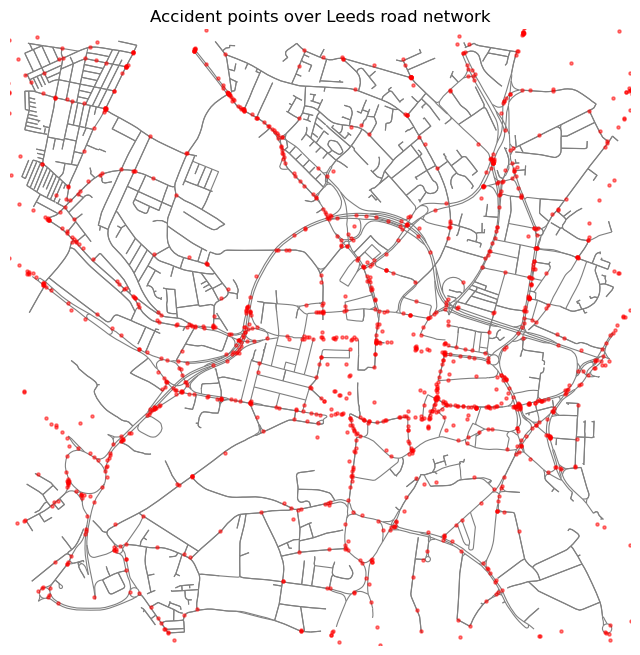

In [181]:
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.8,
    edge_color="gray",
    bgcolor="white",
    show=False,
    close=False
)

gdf_acc_wgs.plot(ax=ax, color="red", markersize=5, alpha=0.5)
plt.title("Accident points over Leeds road network")
plt.show()

In [183]:
# Find a 1 km x 1 KM study area with many accidents
centre_point = gpd.GeoSeries(
    [Point(-1.5492, 53.7997)],
    crs="EPSG:4326"
).to_crs(epsg=27700).iloc[0]

cx, cy = centre_point.x, centre_point.y

search_minx, search_maxx = cx - 1500, cx + 1500
search_miny, search_maxy = cy - 1500, cy + 1500

gdf_search = gdf_acc[
    (gdf_acc.geometry.x >= search_minx) &
    (gdf_acc.geometry.x <= search_maxx) &
    (gdf_acc.geometry.y >= search_miny) &
    (gdf_acc.geometry.y <= search_maxy)
].copy()

print("accidents in search area:", len(gdf_search))

accidents in search area: 1211


In [185]:
from shapely.geometry import box
grid_cells = []
step = 250

for x0 in np.arange(search_minx, search_maxx - 1000 + step, step):
    for y0 in np.arange(search_miny, search_maxy - 1000 + step, step):
        cell = box(x0, y0, x0 + 1000, y0 + 1000)
        count = gdf_search.within(cell).sum()
        grid_cells.append({
            "minx": x0,
            "miny": y0,
            "maxx": x0 + 1000,
            "maxy": y0 + 1000,
            "accident_count": count,
            "geometry": cell
        })
grid = gpd.GeoDataFrame(grid_cells, crs="EPSG:27700")
grid_sorted = grid.sort_values("accident_count", ascending=False)

grid_sorted.head(10)

,minx,miny,maxx,maxy,accident_count,geometry
66,430040.070507,433053.121015,431040.070507,434053.121015,314,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
67,430040.070507,433303.121015,431040.070507,434303.121015,313,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
58,429790.070507,433303.121015,430790.070507,434303.121015,313,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
57,429790.070507,433053.121015,430790.070507,434053.121015,309,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
56,429790.070507,432803.121015,430790.070507,433803.121015,293,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
49,429540.070507,433303.121015,430540.070507,434303.121015,284,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
76,430290.070507,433303.121015,431290.070507,434303.121015,283,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
65,430040.070507,432803.121015,431040.070507,433803.121015,280,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
48,429540.070507,433053.121015,430540.070507,434053.121015,278,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."
75,430290.070507,433053.121015,431290.070507,434053.121015,276,"POLYGON ((4.31e+05 4.33e+05, 4.31e+05 4.34e+05..."


In [187]:
best_cell = grid_sorted.iloc[0]
print(f"Best cell accidents: {best_cell['accident_count']}")
print(f"Bounding box: {best_cell['minx']}, {best_cell['miny']}, {best_cell['maxx']}, {best_cell['maxy']}")
from shapely.geometry import box
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)
cx = (best_cell['minx'] + best_cell['maxx']) / 2
cy = (best_cell['miny'] + best_cell['maxy']) / 2
lon, lat = transformer.transform(cx, cy)

print(f"Study area center: ({lat:.4f}, {lon:.4f})")

Best cell accidents: 314
Bounding box: 430040.0705068268, 433053.12101496395, 431040.0705068268, 434053.12101496395
Study area center: (53.7974, -1.5378)


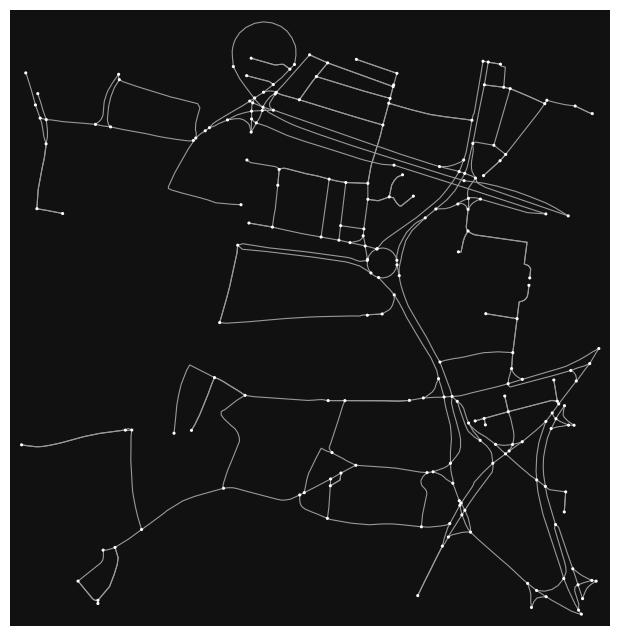

In [189]:
lon_min, lat_min = transformer.transform(best_cell['minx'], best_cell['miny'])
lon_max, lat_max = transformer.transform(best_cell['maxx'], best_cell['maxy'])

study_G = ox.graph_from_point(
    (lat, lon),
    dist=500,
    network_type='drive',
    simplify=True
)

fig, ax = ox.plot_graph(study_G, node_size=5, edge_linewidth=0.8)                                         

In [190]:
print(f" Question 1:")
print(f" Study area coordinates:")
print(f" Center: ({lat:.6f}, {lon:.6f})")
print(f" Radius: 500m")
print(f" Accidents in this area: {best_cell['accident_count']}")

 Question 1:
 Study area coordinates:
 Center: (53.797410, -1.537838)
 Radius: 500m
 Accidents in this area: 314


In [191]:
print(f"Question 2:")
nodes_gdf, edges_gdf = ox.graph_to_gdfs(study_G)

print("=== Road Network Characteristics ===")
print(f"Number of nodes: {study_G.number_of_nodes()}")
print(f"Number of edges: {study_G.number_of_edges()}")

degree_sequence = [d for _, d in study_G.degree()]
avg_degree = sum(degree_sequence) / len(degree_sequence)
print(f"Average degree: {avg_degree:.2f}")

avg_street_length = edges_gdf['length'].mean()
print(f"Average street length: {avg_street_length:.2f} m")

nodes_proj = nodes_gdf.to_crs(epsg=27700)
edges_proj = edges_gdf.to_crs(epsg=27700)

area_km2 = 1.0
print(f"Area: {area_km2} km²")

node_density = study_G.number_of_nodes() / area_km2
print(f"Node density: {node_density:.2f} nodes/km²")

intersections = [n for n, d in study_G.degree() if d >=3]
intersections_density = len(intersections) / area_km2
print(f"Intersection density: {intersections_density:.2f} intersections/km²")

total_edge_length_km = edges_gdf['length'].sum() / 1000
edge_density = total_edge_length_km / area_km2
print(f"Edge density: {edge_density:.2f} km/km²")

from itertools import combinations
from shapely.geometry import MultiPoint

all_points = MultiPoint(list(nodes_proj.geometry))
hull_coords = list(all_points.convex_hull.exterior.coords)
max_dist = 0
for p1, p2 in combinations(hull_coords, 2):
    d = Point(p1).distance(Point(p2))
    if d > max_dist:
        max_dist = d
print(f"Spatial diameter: {max_dist:.2f} m")

largest_cc = max(nx.strongly_connected_components(study_G), key=len)
subG = study_G.subgraph(largest_cc)
net_diameter = nx.diameter(subG, weight='length')
print(f"Network diameter (weighted): {net_diameter:.2f} m")

Question 2:
=== Road Network Characteristics ===
Number of nodes: 212
Number of edges: 352
Average degree: 3.32
Average street length: 58.51 m
Area: 1.0 km²
Node density: 212.00 nodes/km²
Intersection density: 167.00 intersections/km²
Edge density: 20.60 km/km²
Spatial diameter: 1343.83 m
Network diameter (weighted): 1873.75 m


In [221]:
G_proj = ox.project_graph(study_G)

nodes_list = list(G_proj.nodes)
n_samples = 500
circuities = []

for _ in range(n_samples):
    o, d = random.sample(nodes_list, 2)
    try:
        network_dist = nx.shortest_path_length(G_proj, o, d, weight='length')
        ox_node = G_proj.nodes[o]
        dx_node = G_proj.nodes[d]
        euclidean_dist = ((ox_node['x'] - dx_node['x'])**2 +
                          (ox_node['y'] - dx_node['y'])**2)**0.5
        if euclidean_dist > 0:
            circuities.append(network_dist / euclidean_dist)
    except Exception:
        continue
avg_circuity = np.mean(circuities)
print(f"Question 3:")
print(f"Average circuity: {avg_circuity:.4f}")
print(f"(1.0 = perfectly direct; higher = more indirect routes)")
print(f"The average circuity is {avg_circuity:.2f}, meaning routes are ~{avg_circuity:.1f}x longer than straight-line distance.")
print(f"This is higher than typical urban values (1.1-1.3), likely due to one-way streets in the city centre.")

Question 3:
Average circuity: 2.1309
(1.0 = perfectly direct; higher = more indirect routes)
The average circuity is 2.13, meaning routes are ~2.1x longer than straight-line distance.
This is higher than typical urban values (1.1-1.3), likely due to one-way streets in the city centre.


Question 4:
Is the road network planar? False

The network is NOT planar.
This is because road networks have bridges, overpasses, tunnels,
and multi-level intersections that create edge crossings.


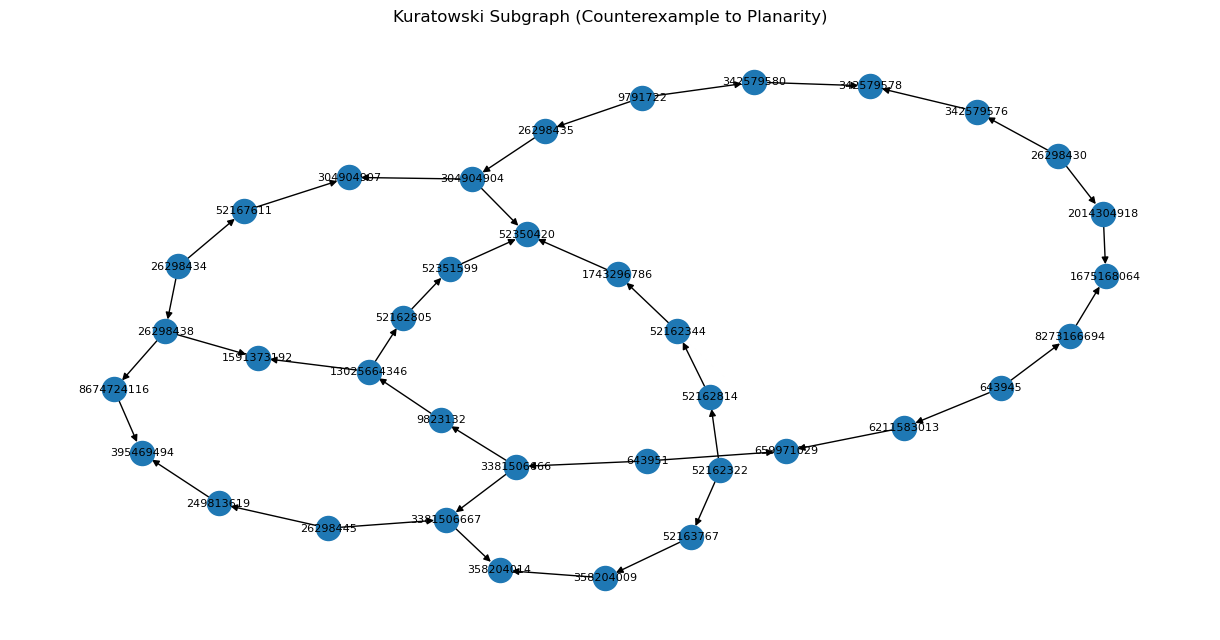

In [193]:
print(f"Question 4:")
is_planar, counterexample = nx.check_planarity(study_G, counterexample=True)
print(f"Is the road network planar? {is_planar}")

if not is_planar:
    print("\nThe network is NOT planar.")
    print("This is because road networks have bridges, overpasses, tunnels,")
    print("and multi-level intersections that create edge crossings.")

    plt.figure(figsize=(12, 6))
    nx.draw(counterexample,
            pos=nx.kamada_kawai_layout(counterexample),
            arrows=True, arrowstyle='-|>',
            with_labels=True, font_size=8)
    plt.title("Kuratowski Subgraph (Counterexample to Planarity)")
    plt.show()
else:
    print("\nThe network IS planar.")
    print("This small area has no overpasses/tunnels,")
    print("so all roads can be drawn on a flat surface without crossings.")


## Task B (road accidents)

Accidents in study area: 314


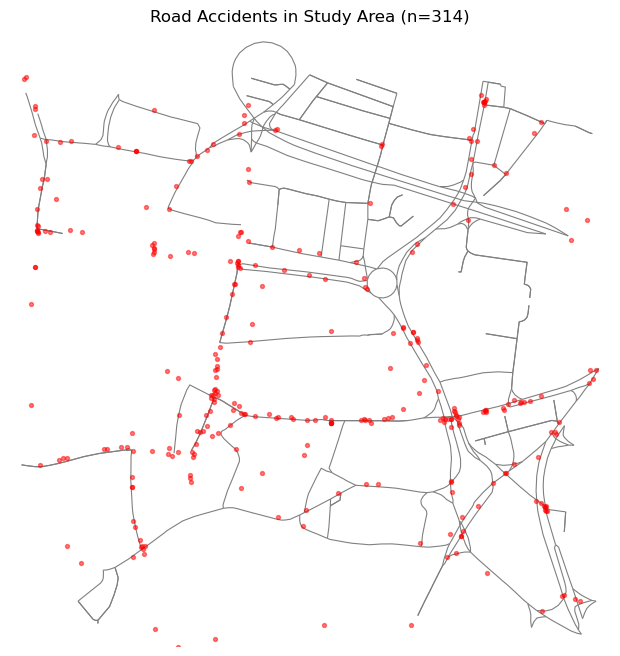

In [195]:
from shapely.geometry import box as shapely_box

study_box = shapely_box(best_cell['minx'], best_cell['miny'],
                        best_cell['maxx'], best_cell['maxy'])
acc_in_study = gdf_acc[gdf_acc.within(study_box)].copy()
acc_in_study_wgs = acc_in_study.to_crs(epsg=4326)

print(f"Accidents in study area: {len(acc_in_study)}")

fig, ax = ox.plot_graph(
    study_G,
    node_size=0,
    edge_linewidth=0.8,
    edge_color='gray',
    bgcolor='white',
    show=False,
    close=False
)
acc_in_study_wgs.plot(ax=ax, color='red', markersize=8, alpha=0.5)
plt.title(f"Road Accidents in Study Area (n={len(acc_in_study)})")
plt.show()

Snapped 314 accidents to network


/opt/anaconda3/lib/python3.12/site-packages/spaghetti/network.py:3412: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  pts = [cg.shapes.Point((p.x, p.y)) for p in pts_objs]
/opt/anaconda3/lib/python3.12/site-packages/spaghetti/util.py:572: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  return cg.Chain([cg.Point(_vcoords[v]) for v in _vs] if _vcoords else _vs)
/opt/anaconda3/lib/python3.12/site-packages/libpysal/cg/shapes.py:1025: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._bounding_box = Rectangle(


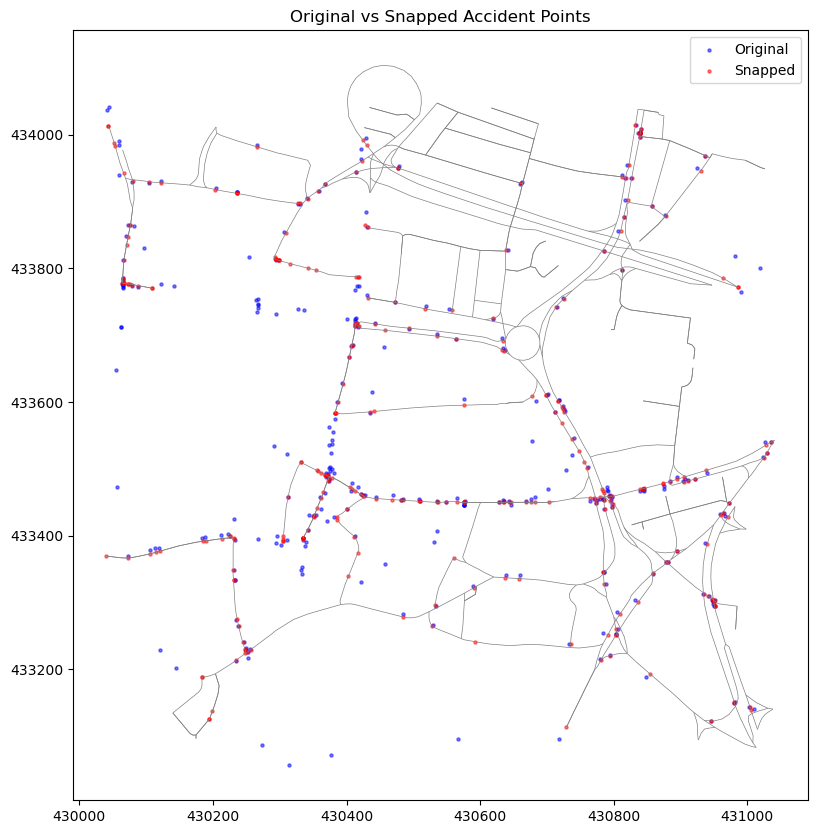

In [196]:
import spaghetti

nodes_gdf, edges_gdf = ox.graph_to_gdfs(study_G)

edges_proj = edges_gdf.to_crs(epsg=27700)

net = spaghetti.Network(in_data=edges_proj)

acc_points = acc_in_study.copy()
acc_points = acc_points.reset_index(drop=True)

net.snapobservations(acc_points, "accidents", attribute=True)

print(f"Snapped {len(net.pointpatterns['accidents'].points)} accidents to network")

fig, ax = plt.subplots(figsize=(10, 10))

edges_proj.plot(ax=ax, color='gray', linewidth=0.5)

acc_points.plot(ax=ax, color='blue', markersize=5, alpha=0.5, label='Original')

pp_gdf = spaghetti.element_as_gdf(net, pp_name="accidents", snapped=True)
pp_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.5, label='Snapped')

ax.legend()
ax.set_title("Original vs Snapped Accident Points")
ax.set_aspect('equal')
plt.show()

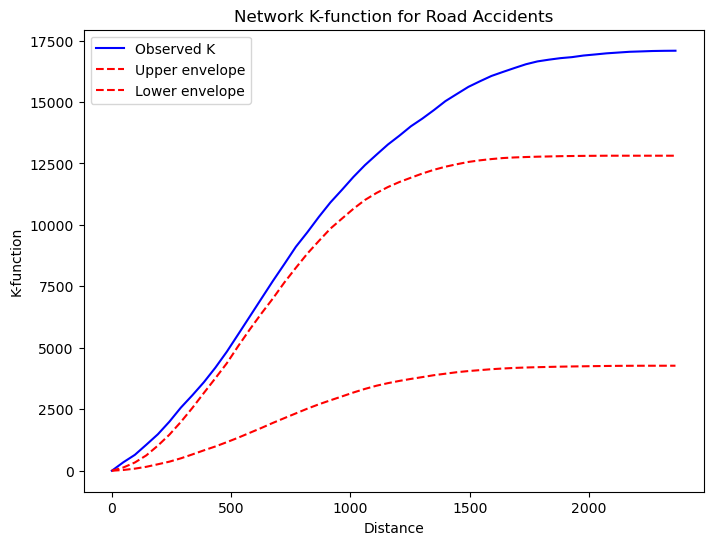

In [197]:
kres = net.GlobalAutoK(
    net.pointpatterns["accidents"],
    nsteps=50,
    permutations=99
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(kres.xaxis, kres.observed, 'b-', label='Observed K')
ax.plot(kres.xaxis, kres.upperenvelope, 'r--', label='Upper envelope')
ax.plot(kres.xaxis, kres.lowerenvelope, 'r--', label='Lower envelope')

ax.set_xlabel("Distance")
ax.set_ylabel("K-function")
ax.set_title("Network K-function for Road Accidents")
ax.legend()
plt.show()

### The observed K-function (blue) lies above the upper envelope (red dashed) at most distances, indicating significant spatial clustering of accidents on the road network. This means accidents are not randomly distributed but tend to concentrate in certain areas.

Moran's I: 0.1582
P-value: 0.0010
Z-score: 6.2891

Expected Moran's I (random): -0.0007757951900698216
Actual Moran's I: 0.15820652581151948


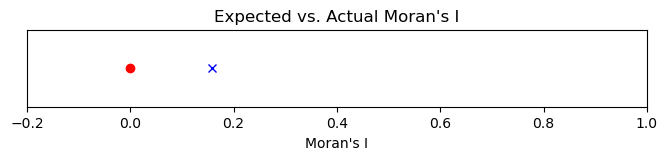

In [199]:
import esda

# Calculate accidents of each link
counts = net.count_per_link(
    net.pointpatterns['accidents'].obs_to_arc,
    graph=False
)

weights = net.w_network
edges_keys = weights.neighbors.keys()

values = [counts[edge] if edge in counts.keys() else 0.0
          for edge in edges_keys]

# Calculate Moran's I
moran = esda.moran.Moran(values, weights)
print(f"Moran's I: {moran.I:.4f}")
print(f"P-value: {moran.p_sim:.4f}")
print(f"Z-score: {moran.z_sim:.4f}")

# Calcuate the expected value under complete spatial randomness"
expected_I = -1 / (len(values) - 1)
print(f"\nExpected Moran's I (random): {expected_I}")
print(f"Actual Moran's I: {moran.I}")

plt.figure(figsize=(8, 1))
plt.plot(expected_I, 0, 'ro')
plt.plot(moran.I, 0, 'bx')
plt.xlim(-0.2, 1)
plt.xlabel("Moran's I")
plt.yticks([])
plt.title("Expected vs. Actual Moran's I")
plt.show()

### Moran's I = 0.16 (p=0.001), indicating statistically significant positive spatial autocorrelation. Accidents tend to cluster on neighbouring roads rather than being randomly distributed.

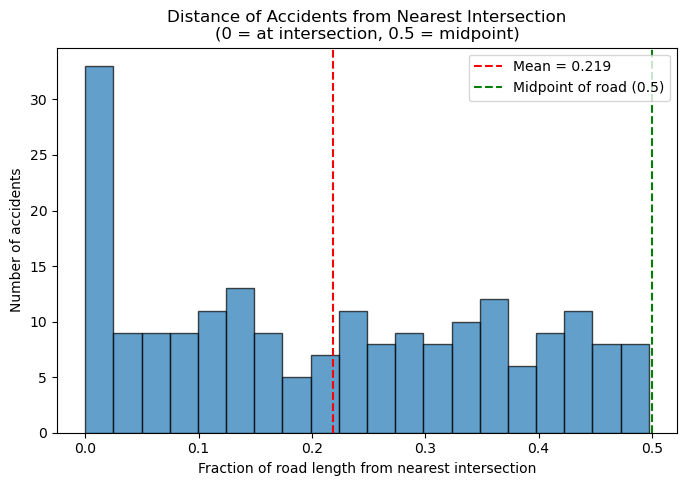

Mean fraction: 0.219
Median fraction: 0.215


In [201]:
pp = net.pointpatterns["accidents"]

fractions = []

for arc_nodes, obs_dict in pp.obs_to_arc.items():
    start = Point(net.vertex_coords[arc_nodes[0]])
    end = Point(net.vertex_coords[arc_nodes[1]])

    arc_length = start.distance(end)

    for obs_id, snapped in obs_dict.items():
        snapped_point = Point(snapped)

        dist_to_start = snapped_point.distance(start)
        dist_to_end = snapped_point.distance(end)

        dist_to_nearest = min(dist_to_start, dist_to_end)

    if arc_length > 0:
        fraction = dist_to_nearest / arc_length
        fractions.append(fraction)

plt.figure(figsize=(8, 5))
plt.hist(fractions, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=np.mean(fractions), color='r', linestyle='--',
            label=f'Mean = {np.mean(fractions):.3f}')
plt.axvline(x=0.5, color='g', linestyle='--',
            label='Midpoint of road (0.5)')
plt.xlabel("Fraction of road length from nearest intersection")
plt.ylabel("Number of accidents")
plt.title("Distance of Accidents from Nearest Intersection\n(0 = at intersection, 0.5 = midpoint)")
plt.legend()
plt.show()

print(f"Mean fraction: {np.mean(fractions):.3f}")
print(f"Median fraction: {np.median(fractions):.3f}")

Mean fraction = 0.219, indicating accidents tend to occur closer to intersections rather than midway along roads. The left-skewed histogram confirms this pattern, suggesting intersections are higher-risk locations.

## Task C (Voronoi diagrams)

Selected seed nodes: [430953004, 7741337466, 3059194351, 643627]


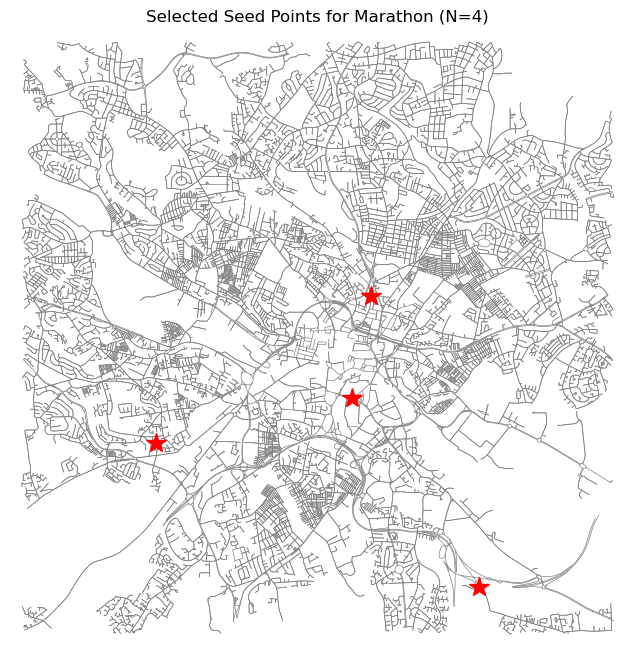

In [204]:
leeds_G = ox.graph_from_point(
    (53.7997, -1.5492),
    dist=5000,
    network_type='drive',
    simplify=True
)

all_nodes = list(leeds_G.nodes)
seeds = random.sample(all_nodes, 4)

print(f"Selected seed nodes: {seeds}")

fig, ax = ox.plot_graph(
    leeds_G,
    node_size=0,
    edge_linewidth=0.5,
    edge_color='gray',
    bgcolor='white',
    show=False,
    close=False
)
nodes_gdf_all = ox.graph_to_gdfs(leeds_G, edges=False)
for s in seeds:
    ax.plot(nodes_gdf_all.loc[s, 'x'], nodes_gdf_all.loc[s, 'y'],
            'r*', markersize=15)
plt.title("Selected Seed Points for Marathon (N=4)")
plt.show()

Seeds were selected randomly from the road network nodes. While more sophisticated criteria (e.g. distance from accident hotspots, proximity to public transport) could be used, random selection ensures an unbiased initial partition of the city.

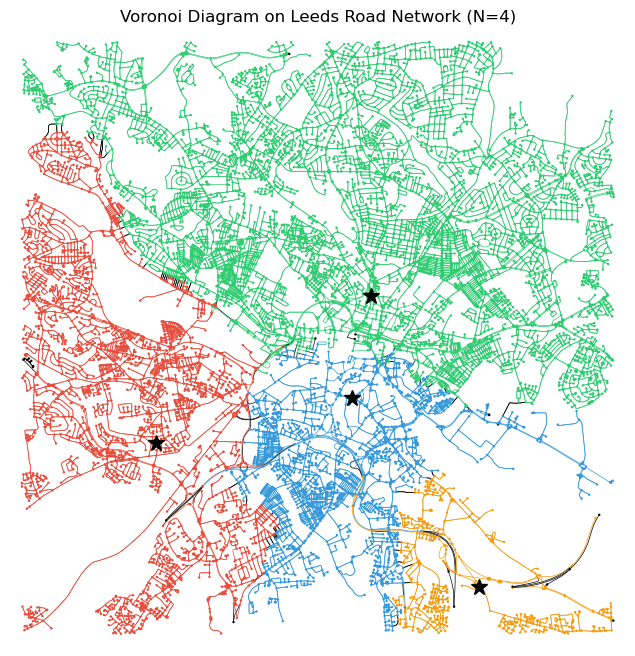

In [206]:
cells = nx.voronoi_cells(leeds_G, seeds, weight='length')

node_to_seed = {}
for seed, cell_nodes in cells. items():
    for node in cell_nodes:
        node_to_seed[node] = seed

import matplotlib.colors as mcolors
seed_colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
seed_color_map = dict(zip(seeds, seed_colors_list))
seed_color_map['unreachable'] = 'black'

nc = []
for node in leeds_G.nodes:
    s = node_to_seed.get(node, 'unreachable')
    nc.append(seed_color_map.get(s, 'black'))

ec = []
for u, v, _ in leeds_G.edges(data=True):
    su = node_to_seed.get(u, 'unreachable')
    sv = node_to_seed.get(v, 'unreachable')
    if su == sv:
        ec.append(seed_color_map.get(su, 'black'))
    else:
        ec.append('black')

fig, ax = ox.plot_graph(
    leeds_G,
    node_color=nc,
    node_size=3,
    edge_color=ec,
    edge_linewidth=0.5,
    bgcolor='white',
    show=False,
    close=False
)

nodes_gdf_all = ox.graph_to_gdfs(leeds_G, edges=False)
for s in seeds:
    ax. plot(nodes_gdf_all.loc[s, 'x'], nodes_gdf_all.loc[s, 'y'],
             'k*', markersize=12)
plt.title("Voronoi Diagram on Leeds Road Network (N=4)")
plt.show()

I use 'nx.voronoi_cells' to construct a node network Voronoi diagram on the Leeds road network. Each node is assigned to the seed that is closest in terms of network shortest-path distance, using raod length as the edge weight. This is more appropriate than a planar Voronoi diagram because marathon participants must travel along roads rather than in straight-line Euclidean space.

In [227]:
def find_marathon_route(graph, seed, cell_nodes, target_length=42000, tolerance=0.05):
    subgraph = graph.subgraph(cell_nodes).copy()

    if not nx.is_strongly_connected(subgraph):
        largest_cc = max(nx.strongly_connected_components(subgraph), key=len)
        subgraph = subgraph.subgraph(largest_cc).copy()

    if seed not in subgraph.nodes:
        seed = list(subgraph.nodes)[0]

    total_edge_length = sum(d.get('length', 0) for u, v, d in subgraph.edges(data=True))
    print(f" Cell total edge length: {total_edge_length/1000:.1f} km")

    if total_edge_length < target_length:
        print(f" WARNING: Cell total edge length ({total_edge_length/1000:.1f} km) < 42 km!")
        print(f" Routes will need to reuse roads.")

    best_route = None
    best_diff = float('inf')

    for attempt in range(100):
        route = [seed]
        current = seed
        total_dist = 0
        half_target = target_length / 2
        visited_edges = set()
        while total_dist < half_target:
            neighbors = list(subgraph.neighbors(current))
            if not neighbors:
                break

            unvisited = [n for n in neighbors
                         if (current, n) not in visited_edges]
            if unvisited:
                next_node = random.choice(unvisited)
            else:
                next_node = random.choice(neighbors)

            edge_data = subgraph[current][next_node]
            if isinstance(edge_data, dict) and 'length' in edge_data:
                edge_len = edge_data['length']
            else:
                edge_len = list(edge_data.values())[0].get('length', 100)

            total_dist += edge_len
            visited_edges.add((current, next_node))
            route.append(next_node)
            current = next_node

        try:
            return_path = nx.shortest_path(subgraph, current, seed, weight='length')
            return_dist = nx.shortest_path_length(subgraph, current, seed, weight='length')

            full_dist = total_dist + return_dist
            diff = abs(full_dist - target_length)

            if diff < best_diff:
                best_diff = diff
                full_route = route + return_path[1:]
                best_route = (full_route, full_dist)
        except nx.NetworkXnoPath:
            continue
    return best_route

for i, (seed, cell_nodes) in enumerate(cells.items()):
    if seed == 'unreachable':
        continue
    print(f"\n=== Cell {i+1} (seed={seed}) ===")
    print(f"  Nodes in cell: {len(cell_nodes)}")

    result = find_marathon_route(leeds_G, seed, cell_nodes)

    if result:
        route, dist = result
        print(f" Best route: {dist/1000:.2f} km ({len(route)} nodes)")
        print(f" Difference from 42km: {abs(dist-42000)/1000:.2f} km")
    else:
        print(f" Could not find a suitable route.")


=== Cell 1 (seed=430953004) ===
  Nodes in cell: 3062
 Cell total edge length: 496.9 km
 Best route: 25.44 km (209 nodes)
 Difference from 42km: 16.56 km

=== Cell 2 (seed=7741337466) ===
  Nodes in cell: 2297
 Cell total edge length: 320.2 km
 Best route: 25.43 km (363 nodes)
 Difference from 42km: 16.57 km

=== Cell 3 (seed=3059194351) ===
  Nodes in cell: 6804
 Cell total edge length: 1159.0 km
 Best route: 26.00 km (333 nodes)
 Difference from 42km: 16.00 km

=== Cell 4 (seed=643627) ===
  Nodes in cell: 585
 Cell total edge length: 78.1 km
 Best route: 25.08 km (204 nodes)
 Difference from 42km: 16.92 km


 Cell total edge length: 496.9 km


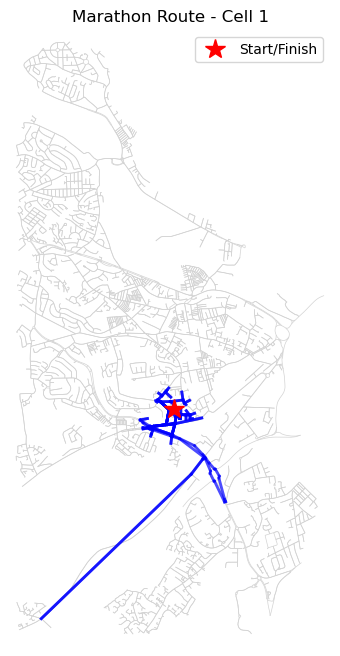

 Cell total edge length: 320.2 km


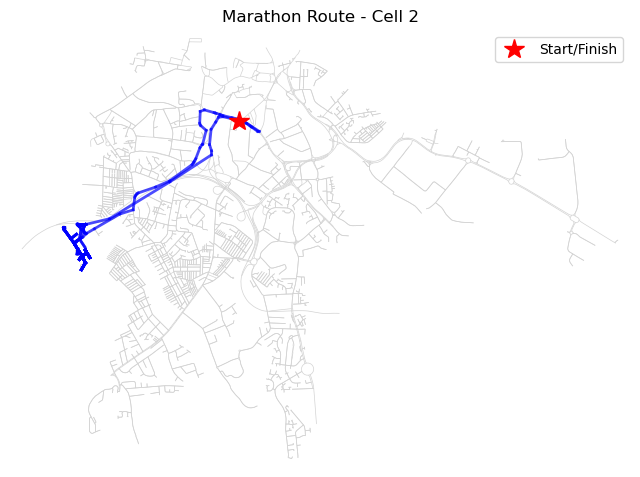

 Cell total edge length: 1159.0 km


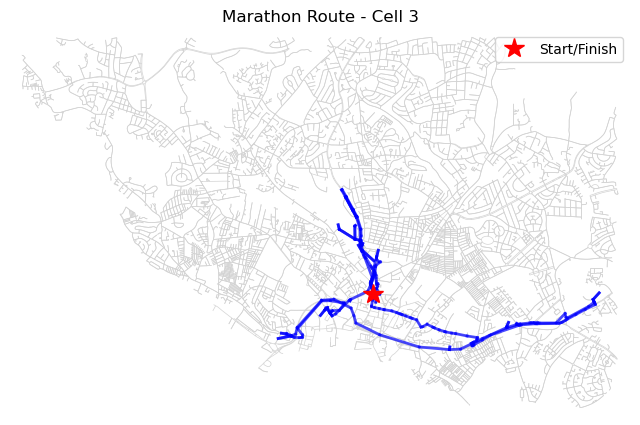

 Cell total edge length: 78.1 km


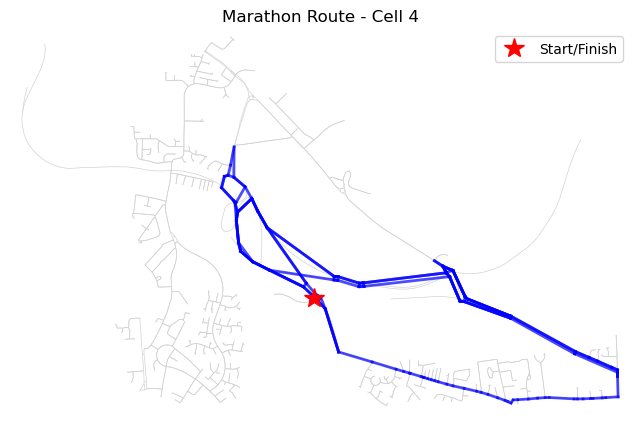

In [237]:
def plot_marathon_route(graph, route, seed, cell_nodes, cell_idx):
    fig, ax = ox.plot_graph(
        graph.subgraph(cell_nodes),
        node_size=0,
        edge_linewidth=0.5,
        edge_color='lightgray',
        bgcolor='white',
        show=False,
        close=False
    )

    route_edges = list(zip(route[:-1], route[1:]))
    nodes_gdf_temp = ox.graph_to_gdfs(graph, edges=False)

    for u, v in route_edges:
        x = [nodes_gdf_temp.loc[u, 'x'], nodes_gdf_temp.loc[v, 'x']]
        y = [nodes_gdf_temp.loc[u, 'y'], nodes_gdf_temp.loc[v, 'y']]
        ax.plot(x, y, 'b-', linewidth=2, alpha=0.7)

    ax.plot(nodes_gdf_temp.loc[seed, 'x'], nodes_gdf_temp.loc[seed, 'y'],
            'r*', markersize=15, label='Start/Finish')

    plt.title(f"Marathon Route - Cell {cell_idx}")
    plt.legend()
    plt.show()

for i, (seed, cell_nodes) in enumerate(cells.items()):
    if seed == 'unreachable':
        continue
    result = find_marathon_route(leeds_G, seed, cell_nodes)
    if result:
        route, dist = result
        plot_marathon_route(leeds_G, route, seed, cell_nodes, i+1)

Routes found are approximately 25km, falling short of the 42km target. Each cell contains sufficient total road length(78-1159km), but the random walk strategy tends to concentrate in a small area rather than exploring the full cell. To achieve 42km routes, possible improvements include: (1) enlarging the study area, (2) reducing the number of seeds to create larger cells, (3) using a more exploratory path-finding algorithm, or (4) allowing routes to traverse roads multiple times.

Selected seed nodes: [300870409, 937018641, 12851370153, 52111010]


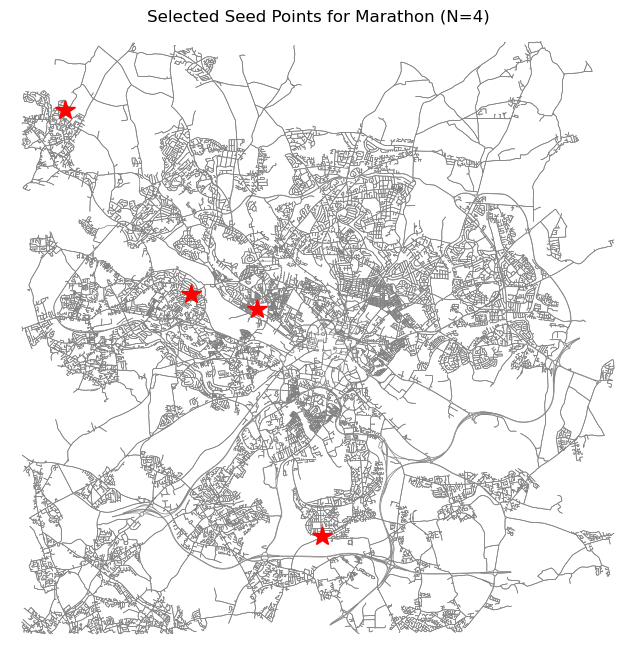

In [256]:
leeds_G_larger = ox.graph_from_point(
    (53.7997, -1.5492),
    dist=10000,
    network_type='drive',
    simplify=True
)

all_nodes = list(leeds_G_larger.nodes)
seeds = random.sample(all_nodes, 4)

print(f"Selected seed nodes: {seeds}")

fig, ax = ox.plot_graph(
    leeds_G_larger,
    node_size=0,
    edge_linewidth=0.5,
    edge_color='gray',
    bgcolor='white',
    show=False,
    close=False
)
nodes_gdf_all = ox.graph_to_gdfs(leeds_G_larger, edges=False)
for s in seeds:
    ax.plot(nodes_gdf_all.loc[s, 'x'], nodes_gdf_all.loc[s, 'y'],
            'r*', markersize=15)
plt.title("Selected Seed Points for Marathon (N=4)")
plt.show()

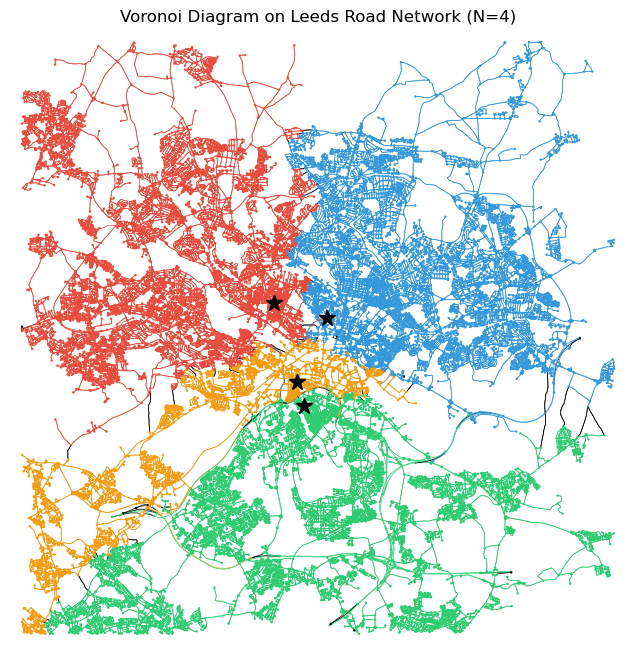

In [252]:
cells = nx.voronoi_cells(leeds_G, seeds, weight='length')

node_to_seed = {}
for seed, cell_nodes in cells. items():
    for node in cell_nodes:
        node_to_seed[node] = seed

import matplotlib.colors as mcolors
seed_colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
seed_color_map = dict(zip(seeds, seed_colors_list))
seed_color_map['unreachable'] = 'black'

nc = []
for node in leeds_G.nodes:
    s = node_to_seed.get(node, 'unreachable')
    nc.append(seed_color_map.get(s, 'black'))

ec = []
for u, v, _ in leeds_G.edges(data=True):
    su = node_to_seed.get(u, 'unreachable')
    sv = node_to_seed.get(v, 'unreachable')
    if su == sv:
        ec.append(seed_color_map.get(su, 'black'))
    else:
        ec.append('black')

fig, ax = ox.plot_graph(
    leeds_G,
    node_color=nc,
    node_size=3,
    edge_color=ec,
    edge_linewidth=0.5,
    bgcolor='white',
    show=False,
    close=False
)

nodes_gdf_all = ox.graph_to_gdfs(leeds_G, edges=False)
for s in seeds:
    ax. plot(nodes_gdf_all.loc[s, 'x'], nodes_gdf_all.loc[s, 'y'],
             'k*', markersize=12)
plt.title("Voronoi Diagram on Leeds Road Network (N=4)")
plt.show()


=== Cell 1 (seed=319425597) ===
  Nodes in cell: 9261
 Cell total edge length: 1670.5 km
 Best route: 23.05 km (313 nodes)
 Difference from 42km: 18.95 km


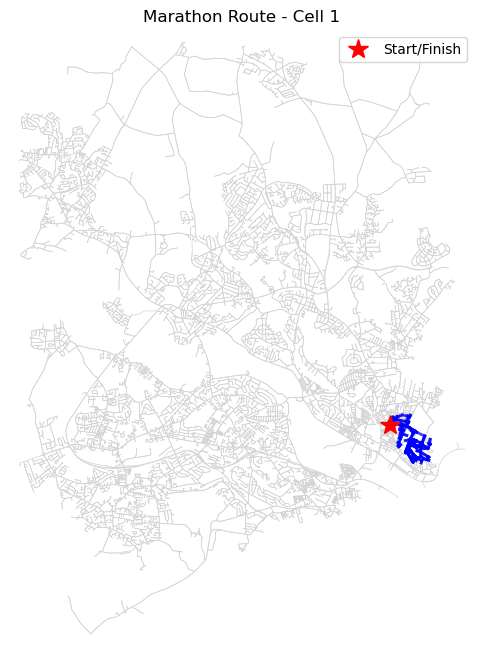


=== Cell 2 (seed=11066706410) ===
  Nodes in cell: 8648
 Cell total edge length: 1636.5 km
 Best route: 27.36 km (360 nodes)
 Difference from 42km: 14.64 km


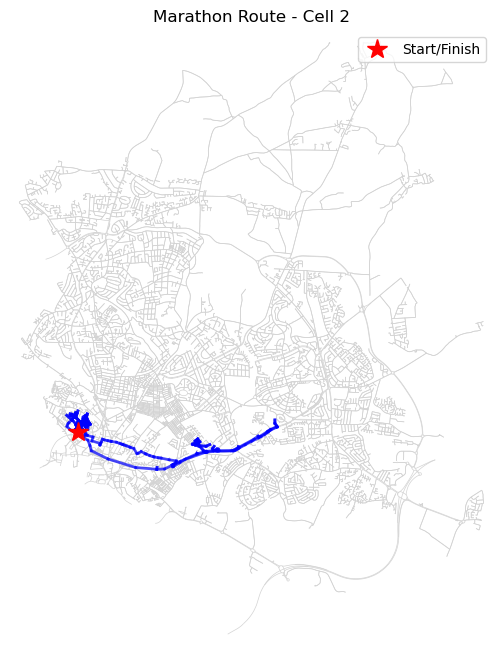


=== Cell 3 (seed=405435090) ===
  Nodes in cell: 8950
 Cell total edge length: 1459.6 km
 Best route: 25.79 km (335 nodes)
 Difference from 42km: 16.21 km


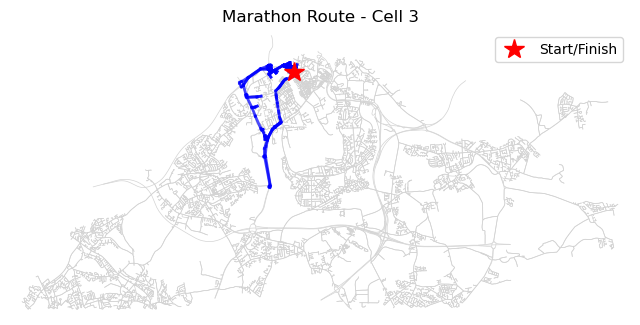


=== Cell 4 (seed=920345791) ===
  Nodes in cell: 3227
 Cell total edge length: 533.4 km
 Best route: 24.72 km (396 nodes)
 Difference from 42km: 17.28 km


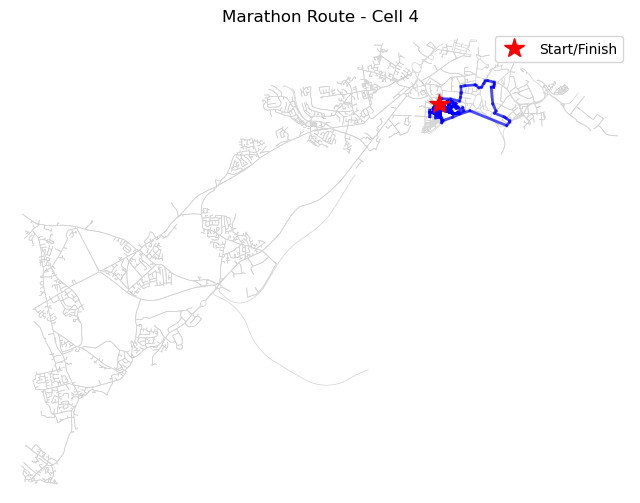

In [258]:
def find_marathon_route(graph, seed, cell_nodes, target_length=42000, tolerance=0.05):
    subgraph = graph.subgraph(cell_nodes).copy()

    if not nx.is_strongly_connected(subgraph):
        largest_cc = max(nx.strongly_connected_components(subgraph), key=len)
        subgraph = subgraph.subgraph(largest_cc).copy()

    if seed not in subgraph.nodes:
        seed = list(subgraph.nodes)[0]

    total_edge_length = sum(d.get('length', 0) for u, v, d in subgraph.edges(data=True))
    print(f" Cell total edge length: {total_edge_length/1000:.1f} km")

    if total_edge_length < target_length:
        print(f" WARNING: Cell total edge length ({total_edge_length/1000:.1f} km) < 42 km!")
        print(f" Routes will need to reuse roads.")

    best_route = None
    best_diff = float('inf')

    for attempt in range(100):
        route = [seed]
        current = seed
        total_dist = 0
        half_target = target_length / 2
        visited_edges = set()
        while total_dist < half_target:
            neighbors = list(subgraph.neighbors(current))
            if not neighbors:
                break

            unvisited = [n for n in neighbors
                         if (current, n) not in visited_edges]
            if unvisited:
                next_node = random.choice(unvisited)
            else:
                next_node = random.choice(neighbors)

            edge_data = subgraph[current][next_node]
            if isinstance(edge_data, dict) and 'length' in edge_data:
                edge_len = edge_data['length']
            else:
                edge_len = list(edge_data.values())[0].get('length', 100)

            total_dist += edge_len
            visited_edges.add((current, next_node))
            route.append(next_node)
            current = next_node

        try:
            return_path = nx.shortest_path(subgraph, current, seed, weight='length')
            return_dist = nx.shortest_path_length(subgraph, current, seed, weight='length')

            full_dist = total_dist + return_dist
            diff = abs(full_dist - target_length)

            if diff < best_diff:
                best_diff = diff
                full_route = route + return_path[1:]
                best_route = (full_route, full_dist)
        except nx.NetworkXnoPath:
            continue
    return best_route

for i, (seed, cell_nodes) in enumerate(cells.items()):
    if seed == 'unreachable':
        continue
    print(f"\n=== Cell {i+1} (seed={seed}) ===")
    print(f"  Nodes in cell: {len(cell_nodes)}")

    result = find_marathon_route(leeds_G_larger, seed, cell_nodes)

    if result:
        route, dist = result
        print(f" Best route: {dist/1000:.2f} km ({len(route)} nodes)")
        print(f" Difference from 42km: {abs(dist-42000)/1000:.2f} km")
        plot_marathon_route(leeds_G_larger, route, seed, cell_nodes, i+1)
    else:
        print(f" Could not find a suitable route.")

 Cell total edge length: 714.8 km


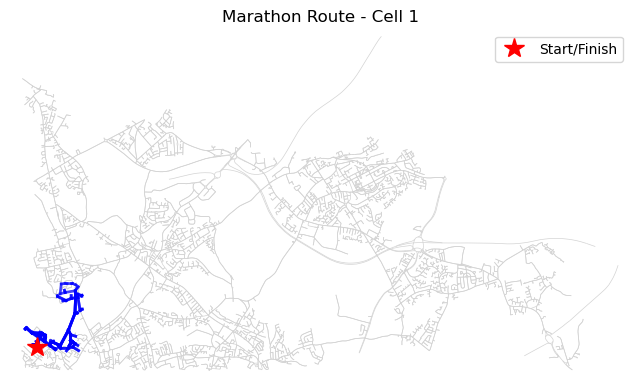

 Cell total edge length: 1127.8 km


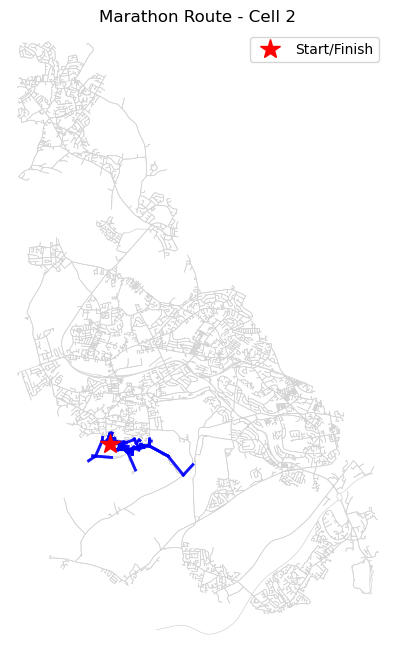

 Cell total edge length: 1713.0 km


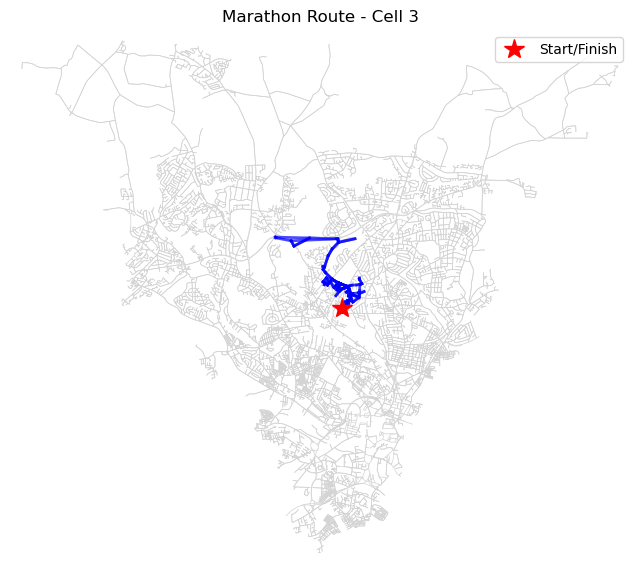

 Cell total edge length: 1729.8 km


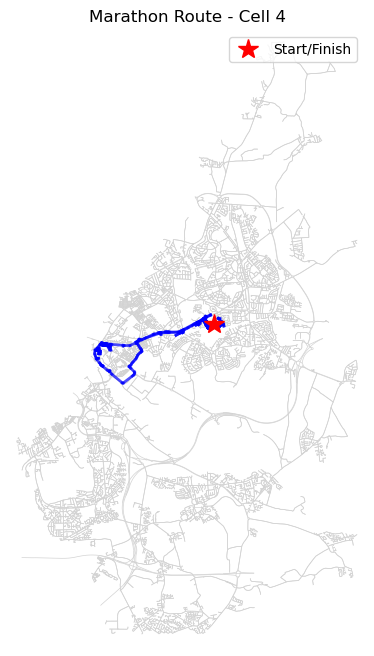

In [246]:
def plot_marathon_route(graph, route, seed, cell_nodes, cell_idx):
    fig, ax = ox.plot_graph(
        graph.subgraph(cell_nodes),
        node_size=0,
        edge_linewidth=0.5,
        edge_color='lightgray',
        bgcolor='white',
        show=False,
        close=False
    )

    route_edges = list(zip(route[:-1], route[1:]))
    nodes_gdf_temp = ox.graph_to_gdfs(graph, edges=False)

    for u, v in route_edges:
        x = [nodes_gdf_temp.loc[u, 'x'], nodes_gdf_temp.loc[v, 'x']]
        y = [nodes_gdf_temp.loc[u, 'y'], nodes_gdf_temp.loc[v, 'y']]
        ax.plot(x, y, 'b-', linewidth=2, alpha=0.7)

    ax.plot(nodes_gdf_temp.loc[seed, 'x'], nodes_gdf_temp.loc[seed, 'y'],
            'r*', markersize=15, label='Start/Finish')

    plt.title(f"Marathon Route - Cell {cell_idx}")
    plt.legend()
    plt.show()

for i, (seed, cell_nodes) in enumerate(cells.items()):
    if seed == 'unreachable':
        continue
    result = find_marathon_route(leeds_G, seed, cell_nodes)
    if result:
        route, dist = result
        plot_marathon_route(leeds_G, route, seed, cell_nodes, i+1)

Routes averaged ~23km despite cells having 1670+ km of roads. The random walk algorithm tends to concentrate near the start rather than exploring the full cell. Improvements could include reducing N to create larger cells, or using a more exploratory path-finding strategy.